## SIM - FLR comparison
Structured notebook to compare EMRI simulated data to fast template.

In [3]:
# imports
import os
os.environ["GPUBACKENDTOOLS_FORCE_BACKEND"] = "cuda12x"

from fastlisaresponse import ResponseWrapper, pyResponseTDI

In [4]:
# from few.waveform import GenerateEMRIWaveform
# from few.trajectory.inspiral import EMRIInspiral

from lisatools.detector import Orbits
from lisaconstants import ASTRONOMICAL_YEAR

import matplotlib.pyplot as plt
import numpy as np
import cupy as cp
import pandas as pd
import os
import h5py
from scipy.signal.windows import tukey
from h5py import File

from scipy.interpolate import CubicSpline

from lisatools.detector import EqualArmlengthOrbits, Orbits
from lisatools.utils.utility import AET

from fastlisaresponse.utils.parallelbase import FastLISAResponseParallelModule
YRSID_SI = ASTRONOMICAL_YEAR
from fastlisaresponse import pyResponseTDI

from multiprocessing.sharedctypes import Value
import numpy as np
from typing import Optional, List
import warnings
from typing import Tuple
from copy import deepcopy

import time
import h5py

In [5]:
home_folder = os.getcwd()

In [6]:
# set up waveform generator
from fastlisaresponse.utils.parallelbase import ParallelModuleBase

class GBWave(ParallelModuleBase):
    def __init__(self, force_backend=None):
        super().__init__(force_backend=force_backend)

    @classmethod
    def supported_backends(cls):
        return ["fastlisaresponse_" + _tmp for _tmp in cls.GPU_RECOMMENDED()]

    def __call__(self, A, f, fdot, iota, phi0, psi, T=1.0, dt=10.0):

        # get the t array
        t = self.xp.arange(0.0, T * YRSID_SI, dt)
        cos2psi = self.xp.cos(2.0 * psi)
        sin2psi = self.xp.sin(2.0 * psi)
        cosiota = self.xp.cos(iota)

        fddot = 11.0 / 3.0 * fdot ** 2 / f

        # phi0 is phi(t = 0) not phi(t = t0)
        phase = (
            2 * np.pi * (f * t + 1.0 / 2.0 * fdot * t ** 2 + 1.0 / 6.0 * fddot * t ** 3)
            - phi0
        )

        hSp = -self.xp.cos(phase) * A * (1.0 + cosiota * cosiota)
        hSc = -self.xp.sin(phase) * 2.0 * A * cosiota

        hp = hSp * cos2psi - hSc * sin2psi
        hc = hSp * sin2psi + hSc * cos2psi
 
        return hp - 1j * hc

In [7]:
gb = GBWave(force_backend=None)

In [8]:
# define response
##======================= Simulation set-up
T = 4.0           
f_s = 0.2         
delta_t = 1/f_s   
dt = delta_t
central_freq=2.816e14

source_number = 6

use_gpu = True


##======================= Response set-up 

orbit_file = f'{home_folder}/orbits/esa-trailing-orbits-mojito_validation_test_2.h5'

force_backend = "cuda12x" if use_gpu else None

index_beta = 7
index_lambda = 6



tdi_kwargs = {
    'tdi': '2nd generation',
    'tdi_chan': 'XYZ',
    'order': 39,
}


In [9]:
T = 4.0  # years
t0 = 10000.0  # time at which signal starts (chops off data at start of waveform where information is not correct)

sampling_frequency = 0.2
dt = 1 / sampling_frequency

In [10]:
# Load EMRI parameters from source catalog. 
home_folder = os.getcwd()

A = 1e-21
f = 1e-3

source_index = 6
EMRI_sources_path = f'{home_folder}/mojito_catalog_standardized_processed.hdf5'
with h5py.File(EMRI_sources_path) as hf:
            M = hf['Binaries']['PrimaryMassSSBFrame'][source_index]
            mu = hf['Binaries']['SecondaryMassSSBFrame'][source_index]
            a = hf['Binaries']['PrimarySpinParameter'][source_index]
            p0 = hf['Binaries']['SemiLatusRectum'][source_index]
            e0 = hf['Binaries']['Eccentricity'][source_index]
            inclination = hf['Binaries']['InclinationAngle'][source_index]
            dist = hf['Binaries']['LuminosityDistance'][source_index]
            ra = hf['Binaries']['RightAscension'][source_index]
            dec = hf['Binaries']['Declination'][source_index]
            qK = hf['Binaries']['PolarAnglePrimarySpin'][source_index]
            phiK = hf['Binaries']['AzimuthalAnglePrimarySpin'][source_index]
            Phi_phi0 = hf['Binaries']['AzimuthalPhase'][source_index]
            Phi_theta0 = hf['Binaries']['PolarPhase'][source_index]
            Phi_r0 = hf['Binaries']['RadialPhase'][source_index]
            z = hf['Binaries']['Redshift'][source_index]

In [11]:
# Load L1 - L0 datasets

# load comparison data
DataFolder = '/scratch/leuven/367/vsc36785/MojitoLight/EMRI_Validation'
sinusoid_pp_file = f'{DataFolder}/EMRI_731d_5s_L1_job6_0_20251210T164134530319Z.h5'

with File(sinusoid_pp_file) as f:
    X_sin = f['tdis/X2'][:]/central_freq
    Y_sin = f['tdis/Y2'][:]/central_freq
    Z_sin = f['tdis/Z2'][:]/central_freq
    l01_t0 = f['tdis/sampling'].attrs['t0']
    l01_dt = f['tdis/sampling'].attrs['dt']
    l01_size = f['tdis/sampling'].attrs['size']
    l01_tspan = np.arange(l01_t0, l01_t0 + l01_size*l01_dt, l01_dt)

In [12]:
from lisaconstants.indexing import LINKS
# Load links from sim

# load links from SIM
DataFolder = '/scratch/leuven/367/vsc36785/MojitoLight/EMRI_Validation'
l0_data_file = 'EMRI_731d_5s_L0_job6_0_20251210T164004576353Z.h5'

with File(f'{DataFolder}/{l0_data_file}') as f:
    y_ts = f['tcb/y'][:]
    offset = int(60.0/delta_t)
    resp_t0 = f.attrs['t0']
    resp_dt = f.attrs['dt']
    resp_size = f.attrs['size']
    resp_tspan = np.arange(resp_t0, resp_t0 + resp_size*delta_t, delta_t)

### Define timing params

In [13]:
from lisaconstants import ASTRONOMICAL_YEAR
from lisaorbits import OEMOrbits

def get_mojito_timing(
        oemorbits,
        dt,
        t_dltt_orbits,
        dt_orbits,
        t_strain_offset,
        n_trim_lolipops,
        n_orbit_buffer,
        window_jaxgbresponse,
    ) -> dict:
        """This function derives all timings relevant for Mojito, and generates the
        orbits file and groundtracking file.
        """
        # round up to integer multiple of `dt`
        duration_mojito_light = np.ceil(2.0 * ASTRONOMICAL_YEAR / dt) * dt

        # time reference from orbits file
        orbits = OEMOrbits.from_included(oemorbits)
        t0_orbits = float(orbits.t_start) + t_dltt_orbits

        # sizes: L1 has "+1" to cover full 2-year extent
        size_l1 = int(np.round(duration_mojito_light / dt)) + 1
        size_l0 = size_l1 + 2 * n_trim_lolipops
        size_strain = size_l0 + int(2 * np.ceil(t_strain_offset / dt))
        size_orbits = (
            int(
                np.ceil(((1 + 2 * window_jaxgbresponse) * size_l0 - 1) * dt / dt_orbits)
            )
            + 1
            + 2 * n_orbit_buffer
        )

        # time definitions
        t0_l0 = (
            t0_orbits + n_orbit_buffer * dt_orbits + window_jaxgbresponse * size_l0 * dt
        )
        t_init = t0_l0 - t_strain_offset
        timing_dict = {
            "dt": dt,
            "t_dltt_orbits": t_dltt_orbits,
            "dt_orbits": dt_orbits,
            "t_strain_offset": t_strain_offset,
            "n_trim_lolipops": n_trim_lolipops,
            "n_orbit_buffer": n_orbit_buffer,
            "window_jaxgbresponse": window_jaxgbresponse,
            "t0_orbits": t0_orbits,
            "size_l1": size_l1,
            "size_l0": size_l0,
            "size_strain": size_strain,
            "size_orbits": size_orbits,
            "t0_l0": t0_l0,
            "t_init": t_init,
        }
        return timing_dict

def create_orbits(oemorbits, timing, dense_orbits_path) -> None:
        """Create orbits file"""
        orbits = OEMOrbits.from_included(oemorbits)
        orbits.write(
            dense_orbits_path,    
            dt=timing["dt_orbits"],   
            size=timing["size_orbits"],
            t0=timing["t0_orbits"],
            mode="w",
        )
dense_orbits_path = f'{home_folder}/orbits/esa_trailing_densely_sampled.h5'

In [14]:
# create timing dictionary

dt = 5
t_dltt_orbits = 10.
dt_orbits = 5000
t_strain_offset = 550
n_trim_lolipops = 1000
n_orbit_buffer = 10
window_jaxgbresponse = 0.5 

oemorbits =  "esa-trailing"


timing = get_mojito_timing(
        oemorbits,
        dt,
        t_dltt_orbits,
        dt_orbits,
        t_strain_offset,
        n_trim_lolipops,
        n_orbit_buffer,
        window_jaxgbresponse)

OEM preferred interpolation method ignored, using spline interpolation (see InterpolatedOrbits for details)


### Check angular coordinates

The switch from reference coordinate systems should not make a difference in the final TDI output. We have the polarization angle $\psi =-2.831678669421924$ in equatorial coordinate system. Now we should transform this angle to the ecliptic coordinate system. 

This is done in the following way, based on the conventions document. 
$$
\begin{align}
    \sin \beta &= \sin\delta \cos \epsilon - \cos\delta \sin \epsilon\sin\alpha\\
    \cos\lambda &= cos\alpha\cos\delta / \cos\beta \\
    \sin \lambda &= [\sin \delta\sin\epsilon+ \cos\delta\cos\epsilon\sin\alpha]/ \cos\beta
\end{align}
$$

For the polarization angle, we have $\psi_0$ is the polarization in the ecliptic reference frame and $\psi$ in the equatorial reference frame.

$$
\psi_0 = \delta_psi + \psi
$$

$$
    \cos\delta\psi = \frac{1}{\cos\beta}\big[\sin \epsilon\sin\delta\sin\alpha + \cos\epsilon\cos\delta\big]
$$
For consistency and sign checks we can use the following formulae:
$$
\begin{align}
    \sin\delta\psi &= -\frac{1}{\cos\beta}\sin\epsilon\cos\alpha\\
    \cos\delta\psi &= \frac{1}{\cos\delta}\big[ -\sin\epsilon\sin\beta\sin\lambda + \cos\epsilon\cos\beta\big] \\
    \sin\delta\psi &= -\frac{1}{\cos\delta}\sin\epsilon\cos\lambda
\end{align}
$$
We can implement this all in a function that does the conversion for us. For the equatorial obliquity, we use the $J2000.0$ equinox. This gives $\epsilon \simeq 23.4$ degrees.

In [15]:
def equatorial_to_ecliptic_psi(alpha, delta, psi_equatorial, epsilon=0.4090677):
    """
    Converts equatorial coordinates to ecliptic and transforms the GW polarization angle.
    
    Args:
        alpha (float): Right Ascension (radians)
        delta (float): Declination (radians)
        psi_equatorial (float): Polarization angle in equatorial frame (radians)
        epsilon (float): Obliquity of the ecliptic. Default is J2000 value (~23.44 deg).
        
    Returns:
        dict: lambda (long), beta (lat), and psi_ecliptic (radians)
    """
    # 1. Compute Ecliptic Latitude (beta)
    # sin(beta) = sin(delta)cos(eps) - cos(delta)sin(eps)sin(alpha)
    sin_beta = np.sin(delta) * np.cos(epsilon) - np.cos(delta) * np.sin(epsilon) * np.sin(alpha)
    beta = np.arcsin(sin_beta)
    cos_beta = np.cos(beta)

    # 2. Compute Ecliptic Longitude (lambda)
    # Use arctan2(sin, cos) for correct quadrant logic
    sin_lam = (np.sin(delta) * np.sin(epsilon) + np.cos(delta) * np.cos(epsilon) * np.sin(alpha)) / cos_beta
    cos_lam = (np.cos(alpha) * np.cos(delta)) / cos_beta
    lam = np.arctan2(sin_lam, cos_lam)

    # 3. Compute Delta Psi (polarization shift)
    # cos(deltapsi) = (sin(eps)sin(delta)sin(alpha) + cos(eps)cos(delta)) / cos(beta)
    # sin(deltapsi) = - (sin(eps)cos(alpha)) / cos(beta)
    cos_dpsi = (np.sin(epsilon) * np.sin(delta) * np.sin(alpha) + np.cos(epsilon) * np.cos(delta)) / cos_beta
    sin_dpsi = -(np.sin(epsilon) * np.cos(alpha)) / cos_beta
    
    deltapsi = np.arctan2(sin_dpsi, cos_dpsi)

    # 4. Final Polarization in Ecliptic frame
    psi_ecliptic = deltapsi + psi_equatorial

    return {
        "lambda": lam,
        "beta": beta,
        "psi_ecliptic": psi_ecliptic,
        "deltapsi": deltapsi
    }

In [16]:
print(f'''
ra = {ra}
dec = {dec}
psi = -2.831678669421924
''')


ra = 3.9684956565955574
dec = 0.7313689457484064
psi = -2.831678669421924



In [17]:
# These are the parameters we have injected in the SIM pipeline. 
psi_eq = -2.831678669421924

In [18]:
results = equatorial_to_ecliptic_psi(
    ra, 
    dec, 
    psi_eq)

print(f"Ecliptic Longitude (λ): {results['lambda']:.6f} rad")
print(f"Ecliptic Latitude (β):  {results['beta']:.6f} rad")
print(f"Polarization (ψ_0):     {results['psi_ecliptic']:.6f} rad")

Ecliptic Longitude (λ): -2.702326 rad
Ecliptic Latitude (β):  0.980211 rad
Polarization (ψ_0):     -2.326811 rad


### response comparison

In [19]:
esa = Orbits(filename=dense_orbits_path, 
            use_gpu=use_gpu, 
            force_backend=force_backend, 
            linear_interp_setup=False)

In [20]:
gb_lisa_esa = ResponseWrapper(
    gb,
    T,
    dt,
    index_lambda,
    index_beta,
    t0=t0,
    flip_hx=True,  # set to True if waveform is h+ - ihx
    force_backend=force_backend,
    remove_sky_coords=True,  # True if the waveform generator does not take sky coordinates
    is_ecliptic_latitude=True,  # False if using polar angle (theta)
    remove_garbage=False,  # removes the beginning of the signal that has bad information
    orbits=esa,
    **tdi_kwargs,
)

In [21]:
sine_params = [
    1e-21,  # A
    1e-3,  # f
    0.0,   # fdot
    0.0,   # iota
    0.0,   # phi0 initial phase
    results['psi_ecliptic'],  # psi polarization angle
    ra,        # lambda - longitude
    dec,                  # beta - latitude
]

In [22]:
chans = gb_lisa_esa(*sine_params)

In [23]:
time = np.arange(len(chans[0])) * dt / YRSID_SI

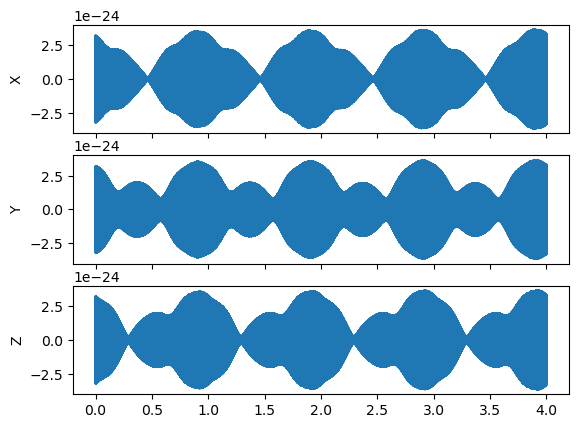

In [24]:
fig, ax = plt.subplots(3, 1, sharex=True)

for i, lab in enumerate(["X", "Y", "Z"]):
    ax[i].plot(time[::10], chans[i].get()[::10])
    # ax[i].set_xlim([1.999, 2.001])
    ax[i].set_ylabel(lab)

In [25]:
y_flr = gb_lisa_esa.response_model.y_gw

In [26]:
T_DLTT_ORBITS = 10.
with File(orbit_file, 'r') as f:
    t0_orbits = f.attrs['t_start'] + T_DLTT_ORBITS

In [27]:
# comparison plots
time_sim_L0 = np.arange(l01_t0, y_ts.shape[0]*delta_t + l01_t0, dt)[:-1] / YRSID_SI 
time_flr_L0 = np.arange(t0_orbits, y_flr.shape[1]*delta_t + t0_orbits, dt)[:-1] /YRSID_SI

0
1
2
3
4
5


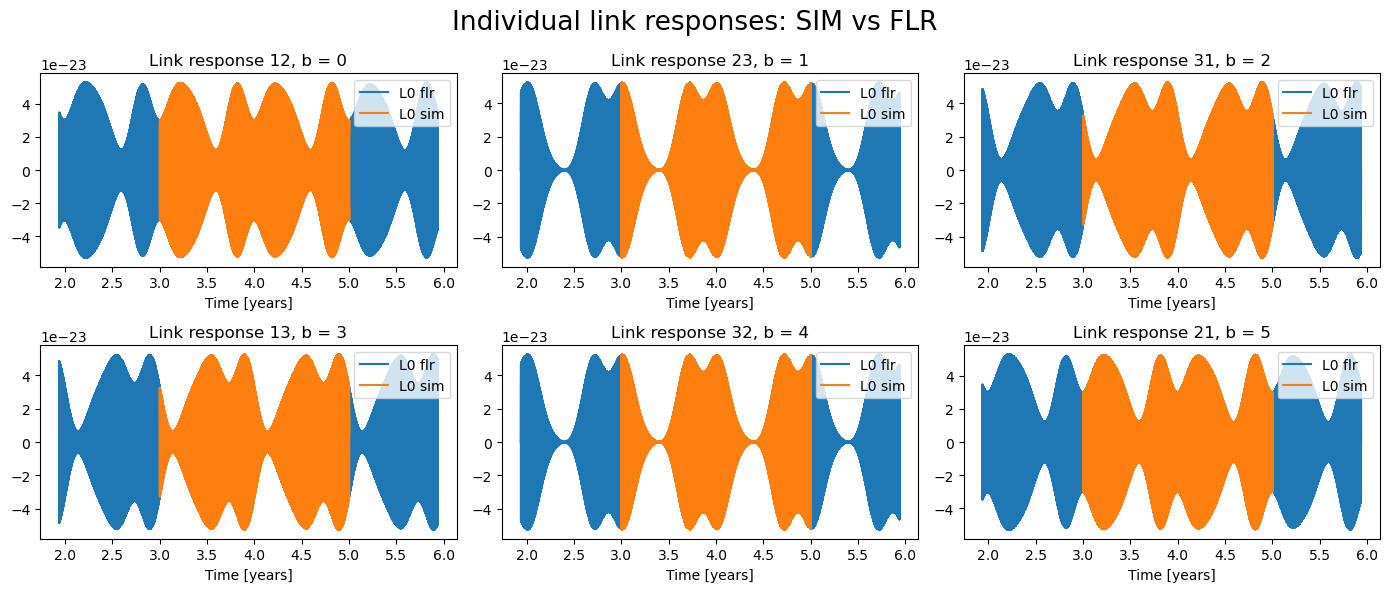

In [28]:
fig, axes = plt.subplots(2, 3, figsize=(14, 6))

for k in range(2):
    for l in range(3):
        b = k * 3 + l
        print(b)
        axes[k, l].plot(time_flr_L0[:-1000][::10], y_flr[b, :-1000].get()[::10], label='L0 flr')
        axes[k, l].plot(time_sim_L0[:-1000][::10], y_ts[:-1000, b][::10], label=f'L0 sim')
      
        axes[k, l].set_xlabel('Time [years]')
        axes[k, l].legend(loc='upper right')
        axes[k, l].set_title(f'Link response {LINKS[b]}, b = {b}')
        
fig.suptitle('Individual link responses: SIM vs FLR', fontsize=19)
plt.tight_layout()

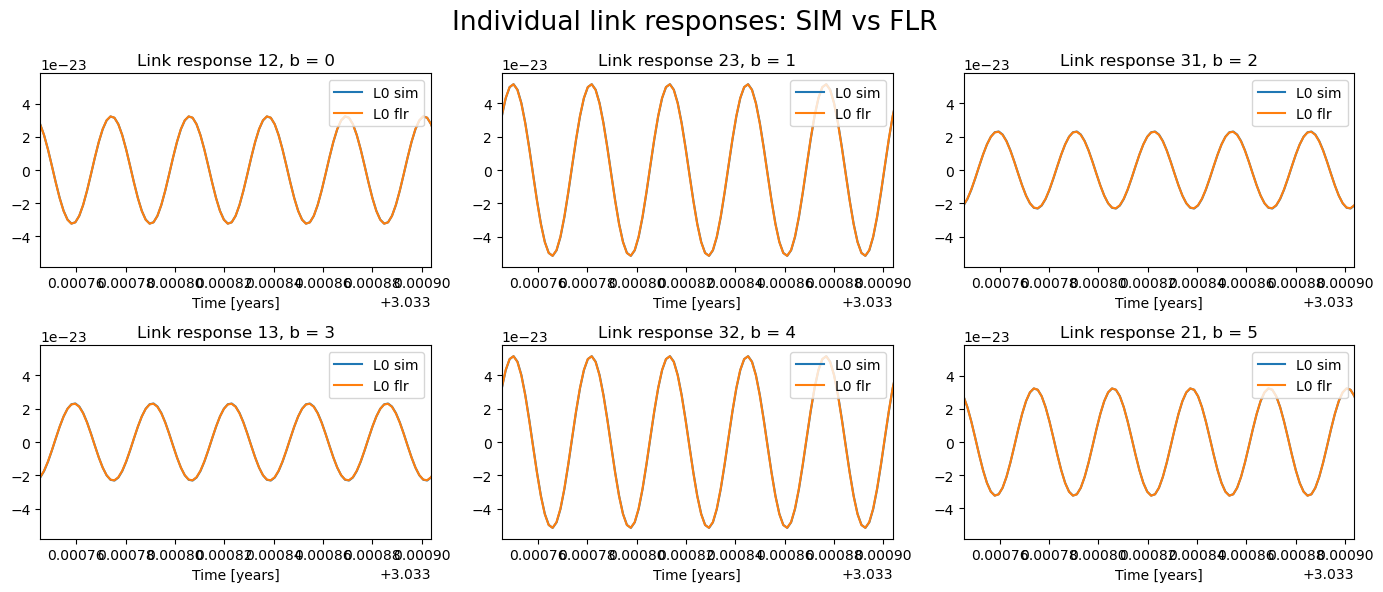

In [29]:
fig, axes = plt.subplots(2, 3, figsize=(14, 6))

for k in range(2):
    for l in range(3):
        b = k * 3 + l
        # print(b)
        starting = 200000
        axes[k, l].plot(time_sim_L0[:-1000][::10], y_ts[:-1000, b][::10], label=f'L0 sim')
        axes[k, l].plot(time_flr_L0[:-1000][::10], y_flr[b, :-1000].get()[::10], label='L0 flr')
        
        # axes[k, l].plot(time_sim_L0[:-1000][::10], y_flr[b, :-1000].get()[::10][] - y_ts[:-1000, b][::10], label=f'Residual')
        axes[k, l].set_xlim([time_sim_L0[0+starting], time_sim_L0[starting+ 1000]])
        axes[k, l].set_xlabel('Time [years]')
        axes[k, l].legend(loc='upper right')
        axes[k, l].set_title(f'Link response {LINKS[b]}, b = {b}')
        
fig.suptitle('Individual link responses: SIM vs FLR', fontsize=19)
plt.tight_layout()

In [30]:
time_sim_L1 = np.arange(l01_t0, X_sin.shape[0]*delta_t + l01_t0, dt)[:-1] / YRSID_SI 
time_flr_L1 = np.arange(t0_orbits, cp.asarray(chans).shape[1]*delta_t + t0_orbits, dt)[:-1] /YRSID_SI

In [31]:
time_sim_L1[0]

np.float64(3.0020578689661406)

In [32]:
(l01_t0 - t0_orbits)/dt

np.float64(6713630.5)

In [33]:
y_flr.shape

(6, 25246519)

In [34]:
chans[0].shape

(25246519,)

In [35]:
# time_flr_reduced = dt* np.arange(len(y_ts[:, 0])) + (l01_t0 - t0_orbits)
signal_reduced = y_flr[:, 6713630:6713630+len(y_ts[:, 0])]

In [36]:
signal_reduced.shape

(6, 12625261)

In [37]:
y_ts.shape

(12625261, 6)

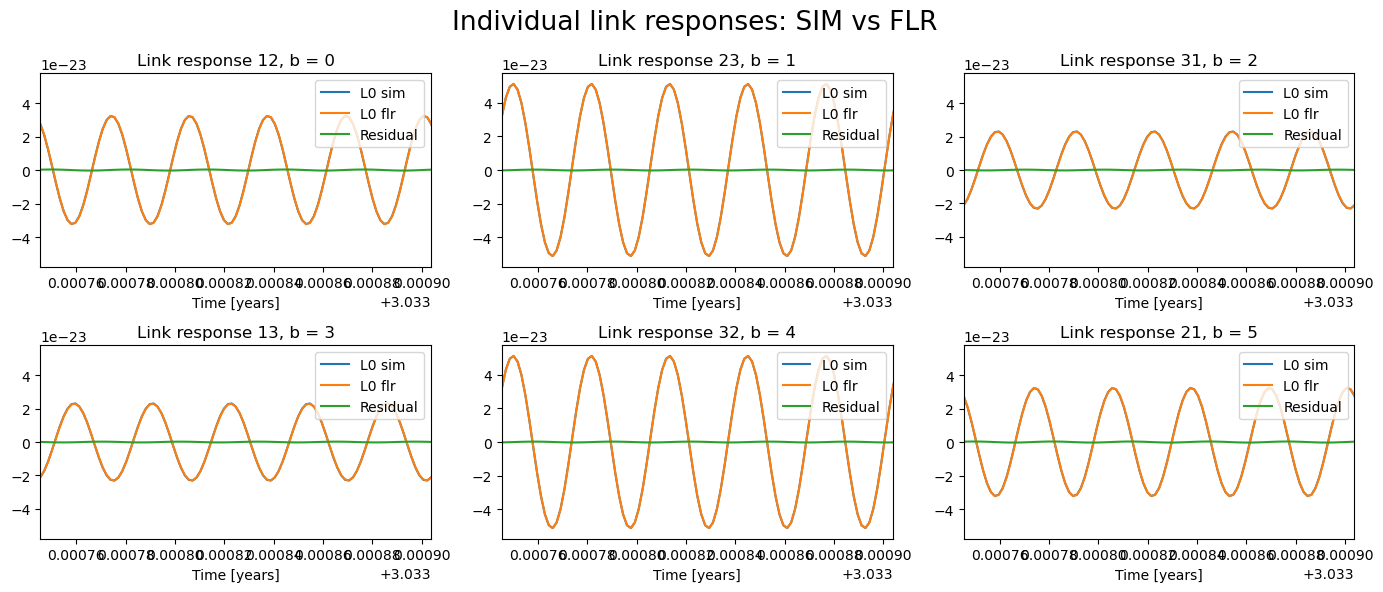

In [38]:
fig, axes = plt.subplots(2, 3, figsize=(14, 6))

for k in range(2):
    for l in range(3):
        b = k * 3 + l
        # print(b)
        starting = 200000
        axes[k, l].plot(time_sim_L0[:-1000][::10], y_ts[:-1000, b][::10], label=f'L0 sim')
        axes[k, l].plot(time_sim_L0[:-1000][::10], signal_reduced[b, :-1000].get()[::10], label='L0 flr')
        
        axes[k, l].plot(time_sim_L0[:-1000][::10], signal_reduced[b, :-1000].T.get()[::10] - y_ts[:-1000, b][::10], label=f'Residual')
        axes[k, l].set_xlim([time_sim_L0[0+starting], time_sim_L0[starting+ 1000]])
        axes[k, l].set_xlabel('Time [years]')
        axes[k, l].legend(loc='upper right')
        axes[k, l].set_title(f'Link response {LINKS[b]}, b = {b}')
        
fig.suptitle('Individual link responses: SIM vs FLR', fontsize=19)
plt.tight_layout()

In [39]:
# Slice TDI output
chans_np = np.asarray([
    chans[i].get() for i in range(3)
])

chans_np_red = chans_np[:, 6713630:6713630+len(X_sin)]

chans_np_red.shape

(3, 12623261)

In [40]:
X_sin.shape

(12623261,)

In [41]:
(time_sim_L1[0]-time_flr_L1[0])/dt

np.float64(0.21273840672862426)

Text(0.5, 1.0, 'TDI X channel')

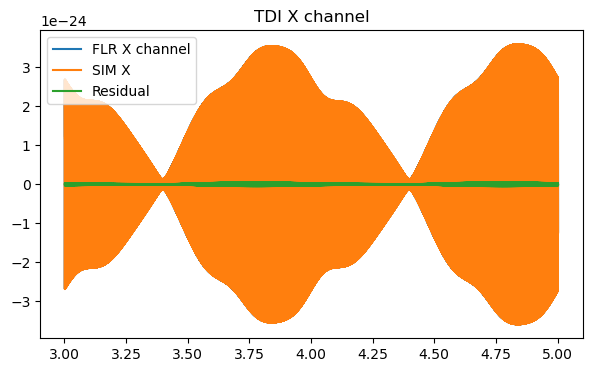

In [42]:
fig, ax = plt.subplots(1, 1, figsize=(7, 4))

ax.plot(time_sim_L1, chans_np_red[0], label='FLR X channel')  
ax.plot(time_sim_L1, X_sin, label='SIM X')   
ax.plot(time_sim_L1, X_sin - chans_np_red[0], label='Residual') 
ax.legend(loc='upper left')
ax.set_title('TDI X channel')

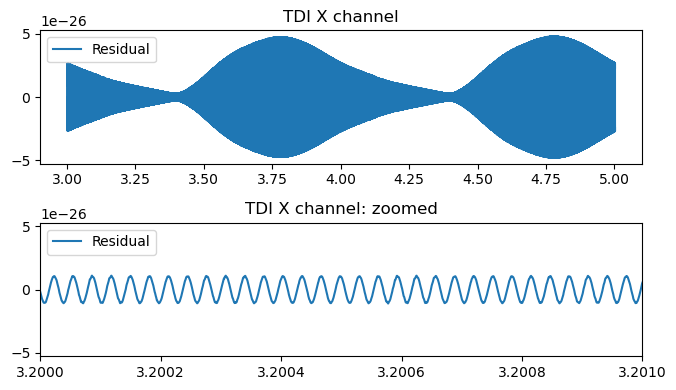

In [45]:
fig, ax = plt.subplots(2, 1, figsize=(7, 4))

ax[0].plot(time_sim_L1, X_sin - chans_np_red[0], label='Residual') 
ax[0].legend(loc='upper left')
ax[0].set_title('TDI X channel')
ax[1].plot(time_sim_L1, X_sin - chans_np_red[0], label='Residual') 
ax[1].set_xlim([3.2, 3.201])
ax[1].legend(loc='upper left')
ax[1].set_title('TDI X channel: zoomed')
plt.tight_layout()

Text(0.5, 1.0, 'TDI X channel')

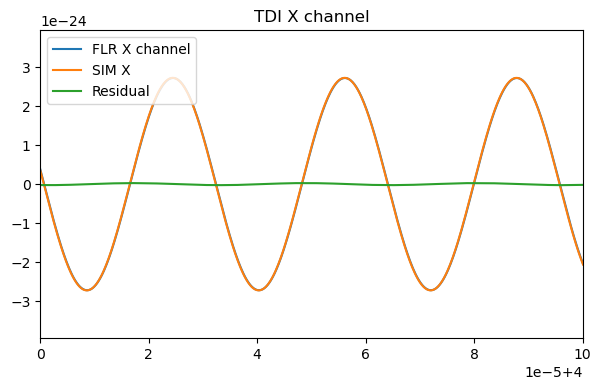

In [84]:
# make zoomed plot
fig, ax = plt.subplots(1, 1, figsize=(7, 4))

ax.plot(time_sim_L1, chans_np_red[0], label='FLR X channel')  
ax.plot(time_sim_L1, X_sin, label='SIM X')   
ax.plot(time_sim_L1, X_sin - chans_np_red[0], label='Residual')
ax.set_xlim([4, 4.0001])
ax.legend(loc='upper left')
ax.set_title('TDI X channel')

Text(0.5, 1.0, 'TDI Y channel')

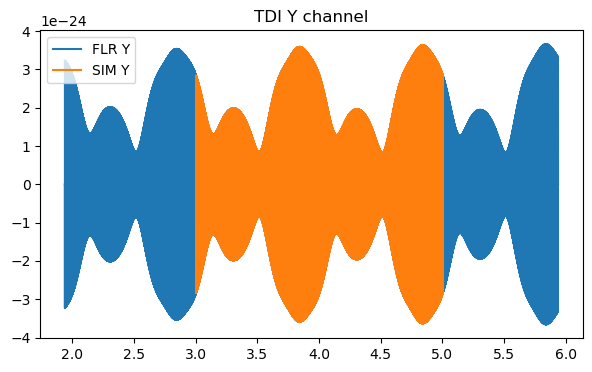

In [57]:
fig, ax = plt.subplots(1, 1, figsize=(7, 4))

ax.plot(time_flr_L1, chans[1].get(), label='FLR Y')
ax.plot(time_sim_L1, Y_sin, label='SIM Y')   

ax.legend(loc='upper left')
ax.set_title('TDI Y channel')

Text(0.5, 1.0, 'TDI Y channel')

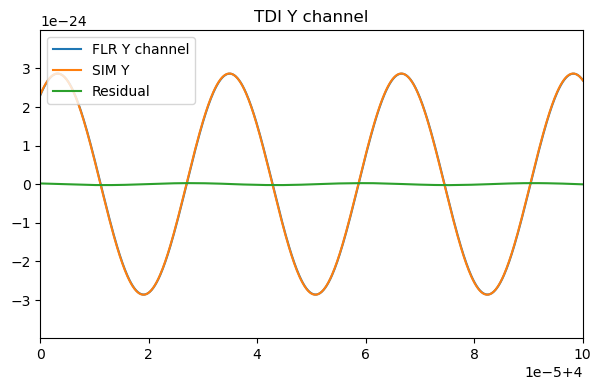

In [85]:
fig, ax = plt.subplots(1, 1, figsize=(7, 4))

ax.plot(time_sim_L1, chans_np_red[1], label='FLR Y channel')  
ax.plot(time_sim_L1, Y_sin, label='SIM Y')   
ax.plot(time_sim_L1, Y_sin - chans_np_red[1], label='Residual')
ax.set_xlim([4, 4.0001])
ax.legend(loc='upper left')
ax.set_title('TDI Y channel')

Text(0.5, 1.0, 'TDI Z channel')

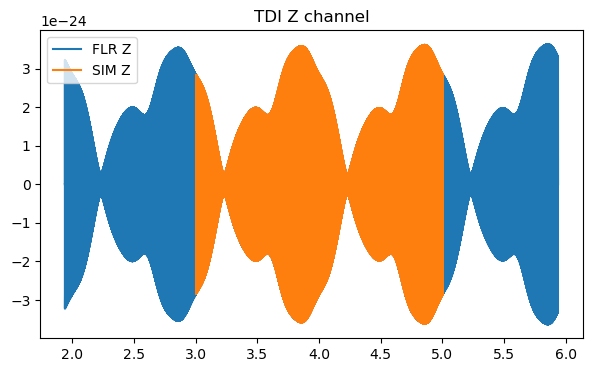

In [58]:
fig, ax = plt.subplots(1, 1, figsize=(7, 4))

ax.plot(time_flr_L1, chans[2].get(), label='FLR Z')
ax.plot(time_sim_L1, Z_sin, label='SIM Z')   

ax.legend(loc='upper left')
ax.set_title('TDI Z channel')

Text(0.5, 1.0, 'TDI Z channel')

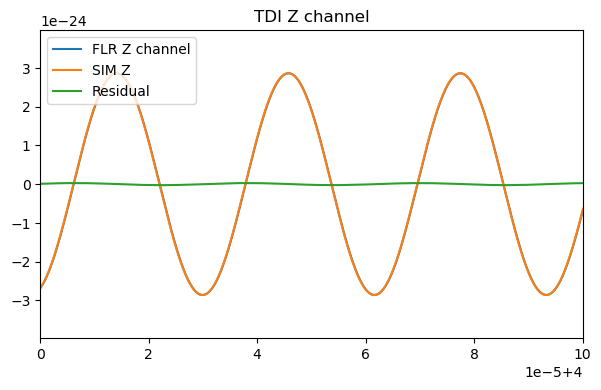

In [87]:
fig, ax = plt.subplots(1, 1, figsize=(7, 4))

ax.plot(time_sim_L1, chans_np_red[2], label='FLR Z channel')  
ax.plot(time_sim_L1, Z_sin, label='SIM Z')   
ax.plot(time_sim_L1, Z_sin - chans_np_red[2], label='Residual')
ax.set_xlim([4, 4.0001])
ax.legend(loc='upper left')
ax.set_title('TDI Z channel')